Has GRU LSTM and Tranformer + RF/SVM/LR/DT initially run + with 5 fold validation


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# 1. SETUP & STRICT GPU CONFIGURATION
# =========================================================
# Ensure CUDA is used
if not torch.cuda.is_available():
    raise SystemError("CUDA is not available! Please check your GPU drivers and PyTorch installation.")

device = torch.device("cuda")
print("="*65)
print(f"[INFO] Using Device  : {device}")
print(f"[INFO] GPU Name      : {torch.cuda.get_device_name(0)}")
print("="*65 + "\n")

# =========================================================
# 2. REAL HDFS DATASET LOADER
# =========================================================
# ---> REPLACE THIS PATH WITH YOUR ACTUAL HDFS.npz PATH <---
DATA_PATH = r"C:\Users\nikhi\OneDrive\Attachments\Desktop\Git_Repos\Log_Anomly_Detection\Dataset\HDFS_v1\preprocessed\HDFS.npz"

def load_real_hdfs(path, max_len=60):
    print(f"[INFO] Loading real dataset from: {path} ...")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at {path}. Please update DATA_PATH.")
    
    data = np.load(path, allow_pickle=True)
    
    # Safely find the keys
    keys = list(data.keys())
    x_key = next((k for k in keys if k.lower() in ("x", "x_data", "data", "features")), keys[0])
    y_key = next((k for k in keys if k.lower() in ("y", "y_data", "label", "labels")),  keys[1])
    
    X_raw = data[x_key]
    y = data[y_key]
    
    # --- FIX 1: ENCODE STRING EVENTS TO INTEGERS ---
    # Find all unique events across all sequences
    unique_events = set()
    for seq in X_raw:
        for event in seq:
            unique_events.add(str(event).strip())
            
    # Map each unique string to a number (1-indexed, reserving 0 for padding)
    event2id = {event: idx + 1 for idx, event in enumerate(sorted(unique_events))}
    print(f"[INFO] Found {len(event2id)} unique string events. Converting to integers...")
    
    # Convert the dataset
    X_encoded = []
    for seq in X_raw:
        X_encoded.append([event2id[str(event).strip()] for event in seq])
    # -----------------------------------------------

    # --- FIX 2: PAD VARIABLE LENGTH SEQUENCES ---
    actual_max = max(len(seq) for seq in X_encoded)
    pad_len = min(actual_max, max_len)
    print(f"[INFO] Padding sequences to length {pad_len}...")
    
    padded_X = np.zeros((len(X_encoded), pad_len), dtype=np.int64)
    for i, seq in enumerate(X_encoded):
        trunc = seq[-pad_len:] if len(seq) > pad_len else seq
        padded_X[i, :len(trunc)] = trunc
        
    X = padded_X
    # --------------------------------------------
        
    # Flatten y if nested
    if y.dtype == object or isinstance(y[0], (list, np.ndarray)):
        y = np.array([val[0] if isinstance(val, (list, np.ndarray)) else val for val in y])

    # Convert string labels to ints
    if y.dtype.kind in ("U", "S", "O"):
        label_map = {"Normal": 0, "Anomaly": 1}
        y = np.array([label_map.get(str(v), int(v)) if not str(v).isdigit() else int(v) for v in y])
    
    print(f"[INFO] Dataset loaded successfully! X shape: {X.shape}, y shape: {y.shape}")
    
    # Return X, y, AND the dynamically calculated vocabulary size
    vocab_size = len(event2id) + 1 # +1 for the 0 padding
    return X.astype(np.int64), y.astype(np.int64), vocab_size

class HDFSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Load and Split Data
X_data, y_data, VOCAB_SIZE = load_real_hdfs(DATA_PATH)

# Stratified split to ensure anomaly ratio is maintained
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.3, stratify=y_data, random_state=42
)

# pin_memory=True speeds up CPU to GPU data transfers
train_loader = DataLoader(HDFSDataset(X_train, y_train), batch_size=256, shuffle=True, pin_memory=True)
test_loader  = DataLoader(HDFSDataset(X_test, y_test), batch_size=256, shuffle=False, pin_memory=True)

# You can now delete the hardcoded VOCAB_SIZE line that was below this in the original script!
EMB_DIM = 64
HIDDEN_SIZE = 128

# =========================================================
# 3. DEEP LEARNING ARCHITECTURES (Feature Extractors)
# =========================================================
# Dynamic Vocab Size: Max value in X_data + 1 (for padding 0)
VOCAB_SIZE = int(np.max(X_data)) + 2 
EMB_DIM = 64
HIDDEN_SIZE = 128

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMB_DIM, HIDDEN_SIZE, num_layers=2, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, 2)
        
    def extract_features(self, x):
        e = self.emb(x)
        _, (hn, _) = self.lstm(e)
        return hn[-1] # Returns shape: (Batch, Hidden_Size)
        
    def forward(self, x):
        return self.fc(self.extract_features(x))

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.gru = nn.GRU(EMB_DIM, HIDDEN_SIZE, num_layers=2, batch_first=True)
        self.fc = nn.Linear(HIDDEN_SIZE, 2)
        
    def extract_features(self, x):
        e = self.emb(x)
        _, hn = self.gru(e)
        return hn[-1] # Returns shape: (Batch, Hidden_Size)
        
    def forward(self, x):
        return self.fc(self.extract_features(x))

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0)) # Automatically moves to GPU with model

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.pos_enc = PositionalEncoding(EMB_DIM)
        enc_layer = nn.TransformerEncoderLayer(d_model=EMB_DIM, nhead=4, dim_feedforward=256, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.fc = nn.Linear(EMB_DIM, 2)
        
    def extract_features(self, x):
        pad_mask = (x == 0)
        e = self.pos_enc(self.emb(x))
        out = self.encoder(e, src_key_padding_mask=pad_mask)
        # Average pooling for the sequence
        mask_f = (~pad_mask).unsqueeze(-1).float()
        pooled = (out * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)
        return pooled # Returns shape: (Batch, Emb_Dim)
        
    def forward(self, x):
        return self.fc(self.extract_features(x))

# =========================================================
# 4. PRE-TRAINING & GPU FEATURE EXTRACTION
# =========================================================
def pretrain_dl_model(model, loader, epochs=3):
    """ Trains the DL model on GPU so feature embeddings represent anomalies well. """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Handling class imbalance in HDFS
    pos_weight = torch.tensor([50.0]).to(device) # Rough estimate for HDFS
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 
    
    model.train()
    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
            
            optimizer.zero_grad()
            logits = model(X_batch)
            
            # Using only the anomaly node for BCE Loss
            loss = criterion(logits[:, 1], y_batch) 
            loss.backward()
            optimizer.step()

def get_extracted_features(model, loader):
    """ Pushes data through GPU, extracts features, and moves back to CPU for Scikit-Learn. """
    model = model.to(device)
    model.eval()
    
    features_list, labels_list = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            # Stop before the FC layer
            feats = model.extract_features(X_batch) 
            
            # Move back to CPU for standard ML classifiers
            features_list.append(feats.cpu().numpy())
            labels_list.append(y_batch.numpy())
            
    return np.vstack(features_list), np.concatenate(labels_list)

# =========================================================
# 5. MAIN PIPELINE (3 DL bases × 4 ML Classifiers = 12 Models)
# =========================================================
dl_models = {
    "LSTM": LSTMModel(),
    "GRU": GRUModel(),
    "Transformer": TransformerModel()
}


ml_models = {
    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy", 
        min_samples_leaf=5, 
        class_weight="balanced", 
        random_state=42
    ),
    
    "Logistic Regression": LogisticRegression(
        penalty="l1", 
        solver="saga", 
        C=1.0, 
        class_weight="balanced", 
        max_iter=50, 
        tol=0.01, 
        random_state=42
    ),
    
    "SVM": SVC(
        kernel="rbf", 
        C=1.0, 
        gamma="scale", 
        class_weight="balanced", 
        probability=True, 
        max_iter=50, 
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        n_jobs=-1, 
        random_state=42
    )
}

print("\nStarting the 3x4 Matrix Evaluation...")

for dl_name, dl_model in dl_models.items():
    print(f"\n{'='*65}")
    print(f"[{dl_name}] Pre-training Deep Learning Extractor on GPU...")
    pretrain_dl_model(dl_model, train_loader, epochs=3)
    
    print(f"[{dl_name}] Extracting High-Dimensional Features...")
    X_train_features, y_train_ml = get_extracted_features(dl_model, train_loader)
    X_test_features, y_test_ml   = get_extracted_features(dl_model, test_loader)
    
    print(f"  --> Extracted Train Shape : {X_train_features.shape}")
    print(f"  --> Replacing Final Layer : Training 4 ML Classifiers")
    print(f"{'-'*65}")
    
    for ml_name, ml_model in ml_models.items():
        # Train ML Model on CPU (using DL-extracted features)
        ml_model.fit(X_train_features, y_train_ml)
        
        # Predict & Evaluate
        preds = ml_model.predict(X_test_features)
        
        acc = accuracy_score(y_test_ml, preds)
        pre = precision_score(y_test_ml, preds, zero_division=0)
        rec = recall_score(y_test_ml, preds, zero_division=0)
        f1  = f1_score(y_test_ml, preds, zero_division=0)
        
        print(f"{ml_name:20s} | Acc: {acc:.4f} | Prec: {pre:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

print("\n[INFO] Run Complete!")

[INFO] Using Device  : cuda
[INFO] GPU Name      : NVIDIA GeForce RTX 4060 Laptop GPU

[INFO] Loading real dataset from: C:\Users\nikhi\OneDrive\Attachments\Desktop\Git_Repos\Log_Anomly_Detection\Dataset\HDFS_v1\preprocessed\HDFS.npz ...
[INFO] Found 29 unique string events. Converting to integers...
[INFO] Padding sequences to length 60...
[INFO] Dataset loaded successfully! X shape: (575061, 60), y shape: (575061,)

Starting the 3x4 Matrix Evaluation...

[LSTM] Pre-training Deep Learning Extractor on GPU...
[LSTM] Extracting High-Dimensional Features...
  --> Extracted Train Shape : (402542, 128)
  --> Replacing Final Layer : Training 4 ML Classifiers
-----------------------------------------------------------------
Decision Tree        | Acc: 0.9997 | Prec: 0.9908 | Rec: 0.9978 | F1: 0.9943


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression  | Acc: 0.9979 | Prec: 0.9331 | Rec: 0.9998 | F1: 0.9653


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM                  | Acc: 0.0293 | Prec: 0.0293 | Rec: 1.0000 | F1: 0.0569
Random Forest        | Acc: 0.9998 | Prec: 0.9947 | Rec: 0.9976 | F1: 0.9961

[GRU] Pre-training Deep Learning Extractor on GPU...
[GRU] Extracting High-Dimensional Features...
  --> Extracted Train Shape : (402542, 128)
  --> Replacing Final Layer : Training 4 ML Classifiers
-----------------------------------------------------------------
Decision Tree        | Acc: 0.9995 | Prec: 0.9886 | Rec: 0.9945 | F1: 0.9915


...

SVM                  | Acc: 0.0293 | Prec: 0.0293 | Rec: 1.0000 | F1: 0.0569
Random Forest        | Acc: 0.9997 | Prec: 0.9945 | Rec: 0.9941 | F1: 0.9943

[Transformer] Pre-training Deep Learning Extractor on GPU...
[Transformer] Extracting High-Dimensional Features...
  --> Extracted Train Shape : (402542, 64)
  --> Replacing Final Layer : Training 4 ML Classifiers
-----------------------------------------------------------------
Decision Tree        | Acc: 0.9997 | Prec: 0.9910 | Rec: 0.9980 | F1: 0.9945


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Logistic Regression  | Acc: 0.9993 | Prec: 0.9786 | Rec: 0.9982 | F1: 0.9883


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=50).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVM                  | Acc: 0.0293 | Prec: 0.0293 | Rec: 1.0000 | F1: 0.0569
Random Forest        | Acc: 0.9998 | Prec: 0.9949 | Rec: 0.9978 | F1: 0.9963

[INFO] Run Complete!


[INFO] Using Device  : cuda
[INFO] GPU Name      : NVIDIA GeForce RTX 4060 Laptop GPU

[INFO] Loading real dataset from: C:\Users\nikhi\OneDrive\Attachments\Desktop\Git_Repos\Log_Anomly_Detection\Dataset\HDFS_v1\preprocessed\HDFS.npz ...
[INFO] Found 29 unique string events. Converting to integers...
[INFO] Padding sequences to length 60...
[INFO] Dataset loaded. X: (575061, 60), y: (575061,)

Starting 5-Fold Cross-Validation  (3 DL × 4 ML = 12 combos × 5 folds)

  FOLD 1 / 5

  [LSTM] Pre-training on fold 1...
  [LSTM] Extracting features...
  ML Model                   Acc    Prec     Rec      F1
  ----------------------------------------------------
  Decision Tree           0.9957  0.8775  0.9908  0.9307


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Logistic Regression     0.9971  0.9202  0.9866  0.9523


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=30).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  SVM                     0.0293  0.0293  1.0000  0.0569
  Random Forest           0.9988  0.9836  0.9765  0.9800

  [GRU] Pre-training on fold 1...
  [GRU] Extracting features...
  ML Model                   Acc    Prec     Rec      F1
  ----------------------------------------------------
  Decision Tree           0.9994  0.9808  0.9991  0.9899


...

  SVM                     0.0293  0.0293  1.0000  0.0569
  Random Forest           0.9998  0.9950  0.9970  0.9960

  [Transformer] Pre-training on fold 5...
  [Transformer] Extracting features...
  ML Model                   Acc    Prec     Rec      F1
  ----------------------------------------------------
  Decision Tree           0.9996  0.9865  0.9985  0.9925


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Logistic Regression     0.9986  0.9536  0.9997  0.9761


c:\Users\nikhi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=30).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


  SVM                     0.0293  0.0293  1.0000  0.0569
  Random Forest           0.9998  0.9950  0.9976  0.9963


  FINAL RESULTS  (mean ± std over 5 folds)

  DL Backbone: LSTM
  ML Model                          Acc           Prec            Rec             F1
  --------------------------------------------------------------------------------
  Decision Tree           0.9986±0.0015  0.9633±0.0432  0.9911±0.0115  0.9765±0.0242
  Logistic Regression     0.9626±0.0711  0.7979±0.3296  0.9802±0.0315  0.8237±0.2894
  SVM                     0.0293±0.0000  0.0293±0.0000  1.0000±0.0000  0.0569±0.0000
  Random Forest           0.9995±0.0004  0.9933±0.0052  0.9912±0.0084  0.9922±0.0064

  DL Backbone: GRU
  ML Model                          Acc           Prec            Rec             F1
  --------------------------------------------------------------------------------
  Decision Tree           0.9996±0.0001  0.9878±0.0040  0.9986±0.0006  0.9932±0.0019
  Logistic Regression     0.9991±0.0004

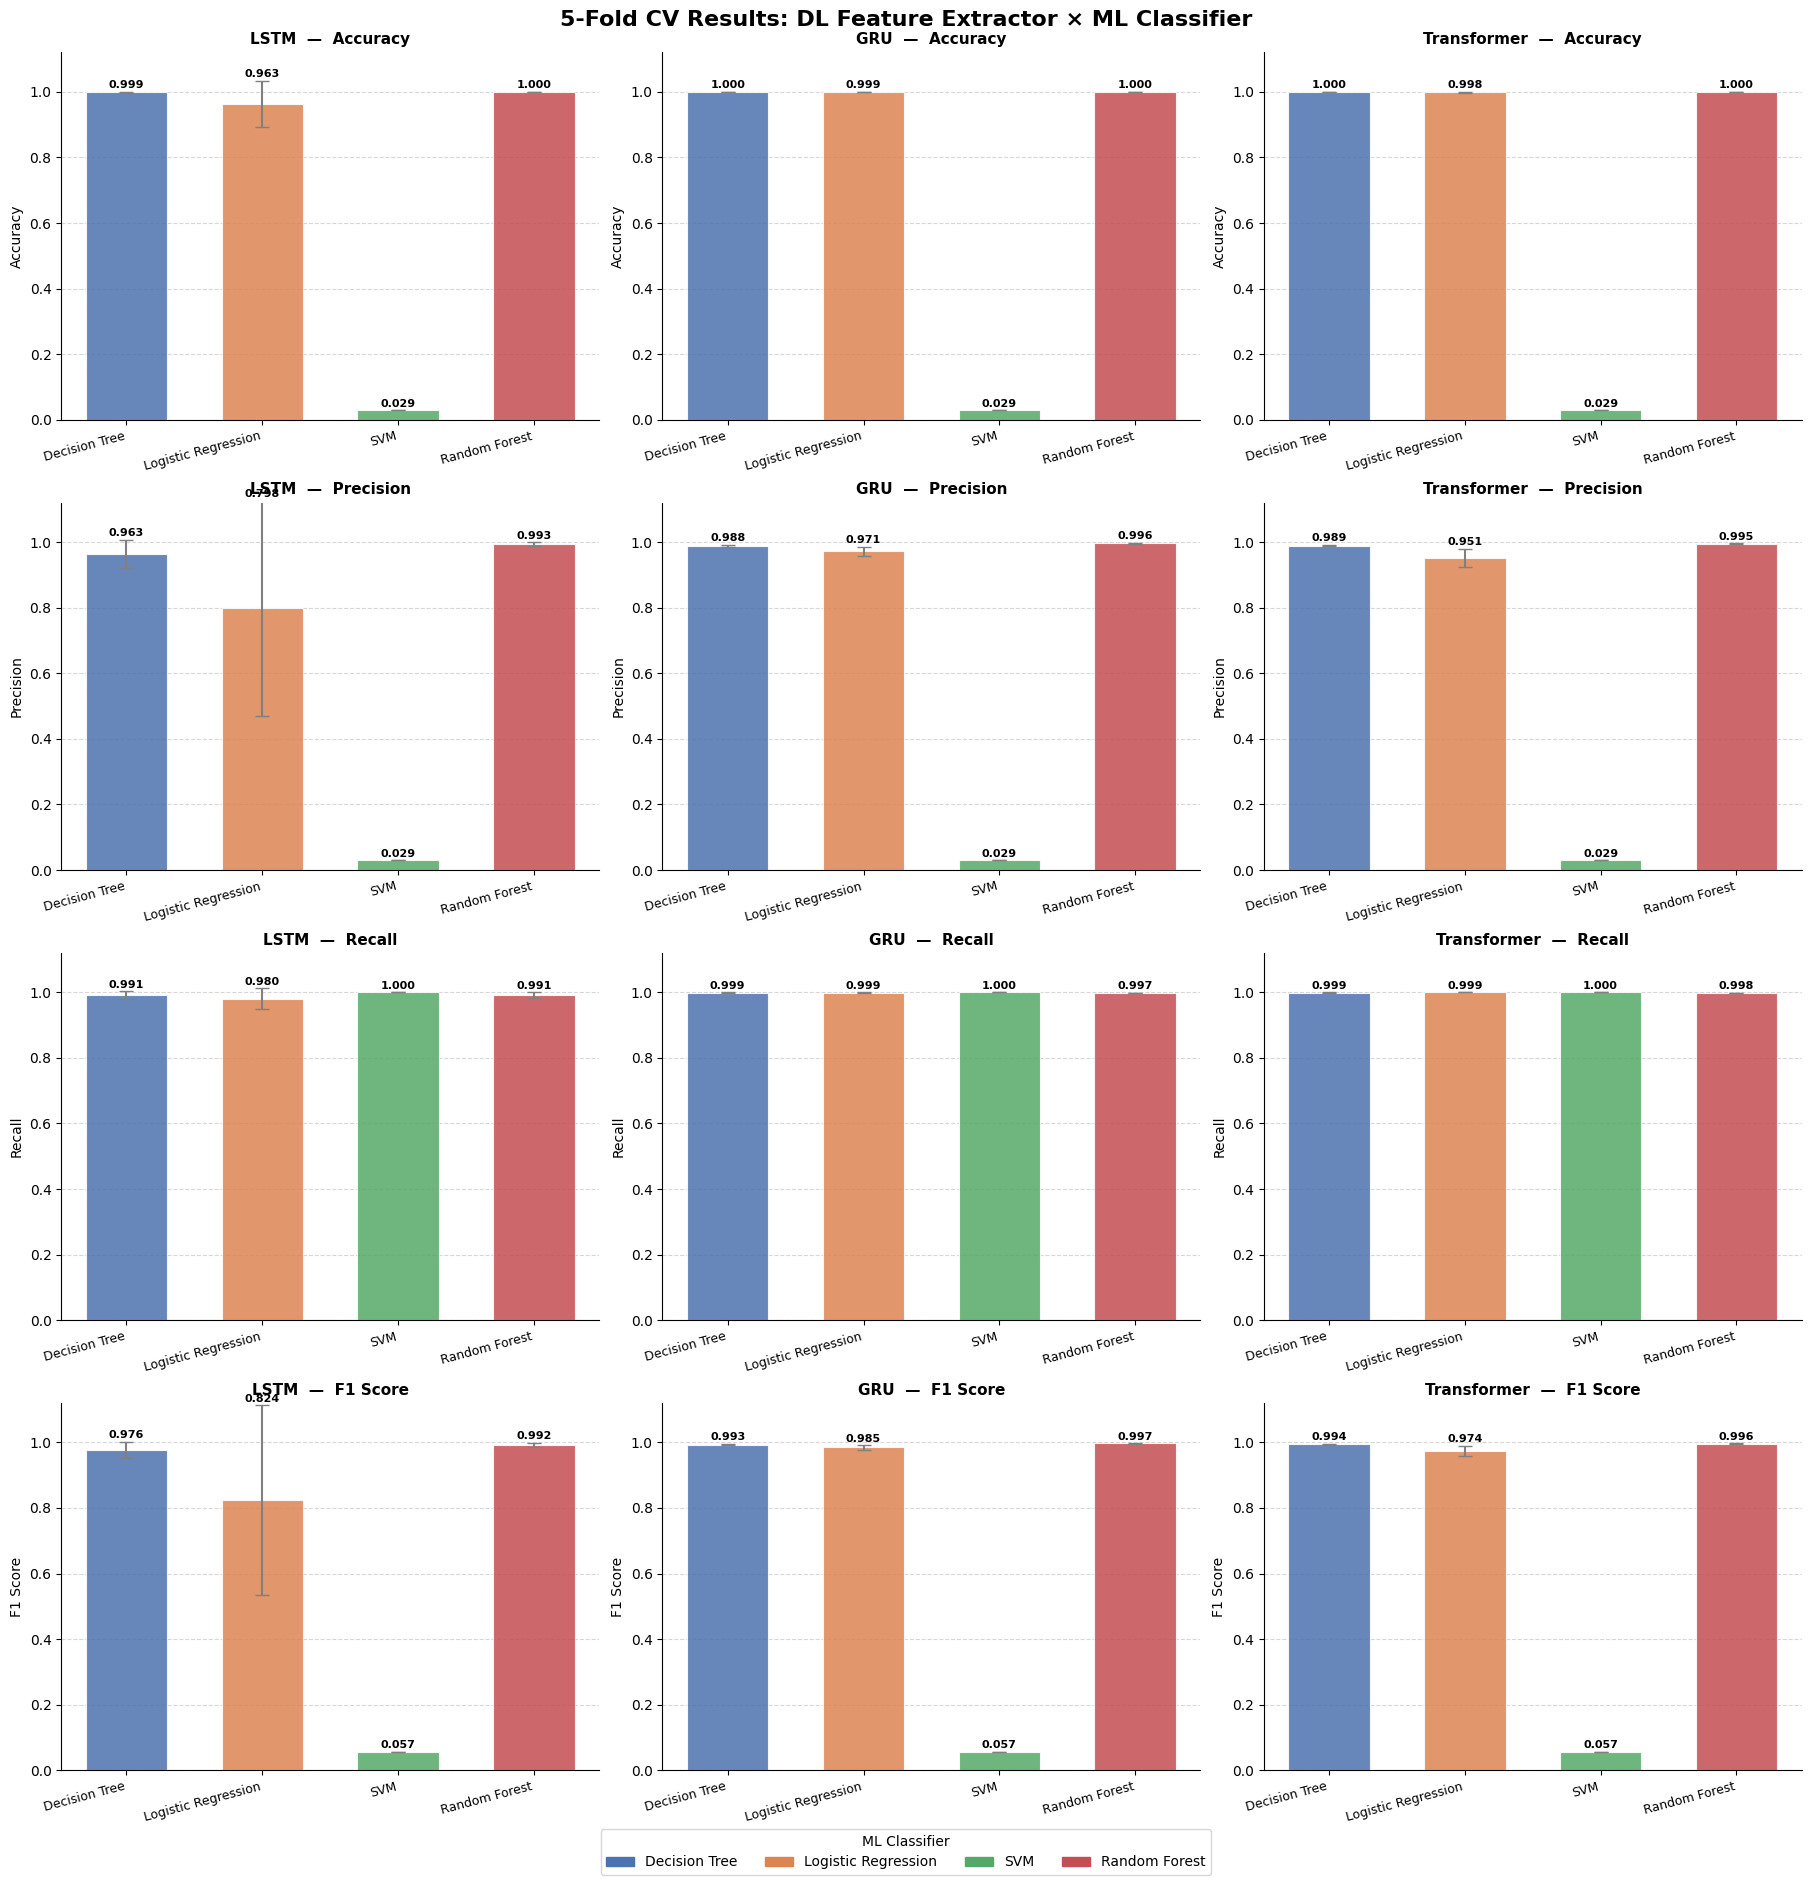


[INFO] Run Complete!


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import os
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# =========================================================
# 1. SETUP & STRICT GPU CONFIGURATION
# =========================================================
if not torch.cuda.is_available():
    raise SystemError("CUDA is not available! Please check your GPU drivers and PyTorch installation.")

device = torch.device("cuda")
print("="*65)
print(f"[INFO] Using Device  : {device}")
print(f"[INFO] GPU Name      : {torch.cuda.get_device_name(0)}")
print("="*65 + "\n")

# =========================================================
# 2. REAL HDFS DATASET LOADER
# =========================================================
DATA_PATH = r"C:\Users\nikhi\OneDrive\Attachments\Desktop\Git_Repos\Log_Anomly_Detection\Dataset\HDFS_v1\preprocessed\HDFS.npz"

DL_EPOCHS     = 3
ML_ITER_SCALE = 10   # LR/SVM iterations = DL_EPOCHS * ML_ITER_SCALE
N_FOLDS       = 5

def load_real_hdfs(path, max_len=60):
    print(f"[INFO] Loading real dataset from: {path} ...")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at {path}. Please update DATA_PATH.")

    data   = np.load(path, allow_pickle=True)
    keys   = list(data.keys())
    x_key  = next((k for k in keys if k.lower() in ("x", "x_data", "data", "features")), keys[0])
    y_key  = next((k for k in keys if k.lower() in ("y", "y_data", "label", "labels")),  keys[1])

    X_raw, y = data[x_key], data[y_key]

    unique_events = set()
    for seq in X_raw:
        for event in seq:
            unique_events.add(str(event).strip())

    event2id  = {event: idx + 1 for idx, event in enumerate(sorted(unique_events))}
    print(f"[INFO] Found {len(event2id)} unique string events. Converting to integers...")

    X_encoded = [[event2id[str(e).strip()] for e in seq] for seq in X_raw]

    pad_len   = min(max(len(s) for s in X_encoded), max_len)
    print(f"[INFO] Padding sequences to length {pad_len}...")

    padded_X  = np.zeros((len(X_encoded), pad_len), dtype=np.int64)
    for i, seq in enumerate(X_encoded):
        trunc = seq[-pad_len:] if len(seq) > pad_len else seq
        padded_X[i, :len(trunc)] = trunc

    if y.dtype == object or isinstance(y[0], (list, np.ndarray)):
        y = np.array([v[0] if isinstance(v, (list, np.ndarray)) else v for v in y])
    if y.dtype.kind in ("U", "S", "O"):
        label_map = {"Normal": 0, "Anomaly": 1}
        y = np.array([label_map.get(str(v), int(v)) if not str(v).isdigit() else int(v) for v in y])

    print(f"[INFO] Dataset loaded. X: {padded_X.shape}, y: {y.shape}")
    return padded_X.astype(np.int64), y.astype(np.int64), len(event2id) + 1


class HDFSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):       return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


X_data, y_data, VOCAB_SIZE_FROM_EVENTS = load_real_hdfs(DATA_PATH)
VOCAB_SIZE  = int(np.max(X_data)) + 2   # override with max-value method (consistent with original)
EMB_DIM     = 64
HIDDEN_SIZE = 128

# =========================================================
# 3. DEEP LEARNING ARCHITECTURES
# =========================================================
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb  = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.lstm = nn.LSTM(EMB_DIM, HIDDEN_SIZE, num_layers=2, batch_first=True)
        self.fc   = nn.Linear(HIDDEN_SIZE, 2)
    def extract_features(self, x):
        _, (hn, _) = self.lstm(self.emb(x))
        return hn[-1]
    def forward(self, x):
        return self.fc(self.extract_features(x))


class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.gru = nn.GRU(EMB_DIM, HIDDEN_SIZE, num_layers=2, batch_first=True)
        self.fc  = nn.Linear(HIDDEN_SIZE, 2)
    def extract_features(self, x):
        _, hn = self.gru(self.emb(x))
        return hn[-1]
    def forward(self, x):
        return self.fc(self.extract_features(x))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TransformerModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb     = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=0)
        self.pos_enc = PositionalEncoding(EMB_DIM)
        enc_layer    = nn.TransformerEncoderLayer(d_model=EMB_DIM, nhead=4, dim_feedforward=256, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.fc      = nn.Linear(EMB_DIM, 2)
    def extract_features(self, x):
        pad_mask = (x == 0)
        e        = self.pos_enc(self.emb(x))
        out      = self.encoder(e, src_key_padding_mask=pad_mask)
        mask_f   = (~pad_mask).unsqueeze(-1).float()
        return (out * mask_f).sum(1) / mask_f.sum(1).clamp(min=1)
    def forward(self, x):
        return self.fc(self.extract_features(x))


# Factory so we always get a fresh model per fold
DL_FACTORIES = {
    "LSTM":        LSTMModel,
    "GRU":         GRUModel,
    "Transformer": TransformerModel,
}

# =========================================================
# 4. PRE-TRAINING & FEATURE EXTRACTION HELPERS
# =========================================================
def pretrain_dl_model(model, loader, epochs=DL_EPOCHS):
    model      = model.to(device)
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3)
    pos_weight = torch.tensor([50.0]).to(device)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    model.train()
    for _ in range(epochs):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.float().to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch)[:, 1], y_batch)
            loss.backward()
            optimizer.step()
    return model


def get_extracted_features(model, loader):
    model.eval()
    feats, labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            feats.append(model.extract_features(X_batch.to(device)).cpu().numpy())
            labels.append(y_batch.numpy())
    return np.vstack(feats), np.concatenate(labels)


def make_ml_models():
    """Return a fresh dict of ML models every call (important: avoids state leaking across folds)."""
    return {
        "Decision Tree": DecisionTreeClassifier(
            criterion="entropy",
            max_depth=DL_EPOCHS * 2,      # scaled to DL depth
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
        ),
        "Logistic Regression": LogisticRegression(
            penalty="l1",
            solver="saga",
            C=1.0,
            class_weight="balanced",
            max_iter=DL_EPOCHS * ML_ITER_SCALE,
            tol=1e-10,
            random_state=42,
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            class_weight="balanced",
            max_iter=DL_EPOCHS * ML_ITER_SCALE,
            probability=True,
            random_state=42,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=DL_EPOCHS * 10,  # scaled tree count
            n_jobs=-1,
            random_state=42,
        ),
    }


# =========================================================
# 5. 5-FOLD CV PIPELINE
# =========================================================
# results[dl_name][ml_name] = list of per-fold dicts {acc, prec, rec, f1}
results = {dl: {ml: [] for ml in make_ml_models()} for dl in DL_FACTORIES}

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"\nStarting {N_FOLDS}-Fold Cross-Validation  ({len(DL_FACTORIES)} DL × {len(make_ml_models())} ML = "
      f"{len(DL_FACTORIES)*len(make_ml_models())} combos × {N_FOLDS} folds)\n")

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_data, y_data)):
    print(f"{'='*65}")
    print(f"  FOLD {fold_idx + 1} / {N_FOLDS}")
    print(f"{'='*65}")

    X_tr, y_tr = X_data[train_idx], y_data[train_idx]
    X_val, y_val = X_data[val_idx],  y_data[val_idx]

    train_loader = DataLoader(HDFSDataset(X_tr,  y_tr),  batch_size=256, shuffle=True,  pin_memory=True)
    val_loader   = DataLoader(HDFSDataset(X_val, y_val), batch_size=256, shuffle=False, pin_memory=True)

    for dl_name, dl_factory in DL_FACTORIES.items():
        print(f"\n  [{dl_name}] Pre-training on fold {fold_idx+1}...")

        # Fresh model each fold — critical for proper CV
        dl_model = pretrain_dl_model(dl_factory(), train_loader, epochs=DL_EPOCHS)

        print(f"  [{dl_name}] Extracting features...")
        X_tr_feat,  y_tr_ml  = get_extracted_features(dl_model, train_loader)
        X_val_feat, y_val_ml = get_extracted_features(dl_model, val_loader)

        print(f"  {'ML Model':<22} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
        print(f"  {'-'*52}")

        for ml_name, ml_model in make_ml_models().items():
            ml_model.fit(X_tr_feat, y_tr_ml)
            preds = ml_model.predict(X_val_feat)

            fold_metrics = {
                "acc":  accuracy_score(y_val_ml, preds),
                "prec": precision_score(y_val_ml, preds, zero_division=0),
                "rec":  recall_score(y_val_ml, preds, zero_division=0),
                "f1":   f1_score(y_val_ml, preds, zero_division=0),
            }
            results[dl_name][ml_name].append(fold_metrics)

            print(f"  {ml_name:<22} {fold_metrics['acc']:>7.4f} {fold_metrics['prec']:>7.4f} "
                  f"{fold_metrics['rec']:>7.4f} {fold_metrics['f1']:>7.4f}")

# =========================================================
# 6. AGGREGATE RESULTS (mean ± std across folds)
# =========================================================
print(f"\n\n{'='*65}")
print("  FINAL RESULTS  (mean ± std over 5 folds)")
print(f"{'='*65}")

summary = {}   # summary[dl_name][ml_name] = {metric: (mean, std)}
metrics_list = ["acc", "prec", "rec", "f1"]

for dl_name in DL_FACTORIES:
    print(f"\n  DL Backbone: {dl_name}")
    print(f"  {'ML Model':<22} {'Acc':>14} {'Prec':>14} {'Rec':>14} {'F1':>14}")
    print(f"  {'-'*80}")
    summary[dl_name] = {}

    for ml_name in make_ml_models():
        fold_data = results[dl_name][ml_name]
        summary[dl_name][ml_name] = {}

        row = f"  {ml_name:<22}"
        for m in metrics_list:
            vals = [f[m] for f in fold_data]
            mean, std = np.mean(vals), np.std(vals)
            summary[dl_name][ml_name][m] = (mean, std)
            row += f"  {mean:.4f}±{std:.4f}"
        print(row)

# =========================================================
# 7. VISUALISATION
# =========================================================
dl_names = list(DL_FACTORIES.keys())
ml_names = list(make_ml_models().keys())
metric_labels = {"acc": "Accuracy", "prec": "Precision", "rec": "Recall", "f1": "F1 Score"}

# --- Color palette (one colour per ML model) ---
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
ml_colors = dict(zip(ml_names, colors))

fig, axes = plt.subplots(
    nrows=len(metrics_list),
    ncols=len(dl_names),
    figsize=(6 * len(dl_names), 4.5 * len(metrics_list)),
    constrained_layout=True,
)
fig.suptitle("5-Fold CV Results: DL Feature Extractor × ML Classifier", fontsize=16, fontweight="bold", y=1.01)

x_pos = np.arange(len(ml_names))
bar_width = 0.6

for col, dl_name in enumerate(dl_names):
    for row, metric_key in enumerate(metrics_list):
        ax = axes[row][col]

        means = [summary[dl_name][ml][metric_key][0] for ml in ml_names]
        stds  = [summary[dl_name][ml][metric_key][1] for ml in ml_names]

        bars = ax.bar(
            x_pos, means, bar_width,
            yerr=stds, capsize=5,
            color=[ml_colors[ml] for ml in ml_names],
            alpha=0.85, edgecolor="white", linewidth=0.8,
            error_kw={"elinewidth": 1.5, "ecolor": "gray"},
        )

        # Value labels on top of bars
        for bar, mean_val, std_val in zip(bars, means, stds):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                mean_val + std_val + 0.005,
                f"{mean_val:.3f}",
                ha="center", va="bottom", fontsize=8, fontweight="bold",
            )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(ml_names, rotation=15, ha="right", fontsize=9)
        ax.set_ylim(0, 1.12)
        ax.set_ylabel(metric_labels[metric_key], fontsize=10)
        ax.set_title(f"{dl_name}  —  {metric_labels[metric_key]}", fontsize=11, fontweight="bold")
        ax.yaxis.grid(True, linestyle="--", alpha=0.5)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

# Legend
legend_patches = [mpatches.Patch(color=ml_colors[ml], label=ml) for ml in ml_names]
fig.legend(handles=legend_patches, loc="lower center", ncol=len(ml_names),
           bbox_to_anchor=(0.5, -0.03), fontsize=10, title="ML Classifier", title_fontsize=10)

out_path = os.path.join(os.path.dirname(DATA_PATH), "cv_results.png")
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"\n[INFO] Chart saved to: {out_path}")
plt.show()

print("\n[INFO] Run Complete!")